<a href="https://colab.research.google.com/github/Future-Analyst/Tensorflow-Exercises-/blob/main/03_CNN_exercise_usign_cifar10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# import the neccessary dependecies
import pandas as pd
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, MaxPool2D, Conv2D
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.preprocessing.image import ImageDataGenerator


from tensorflow.keras.datasets import cifar10

In [ ]:
# Load the CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Limit the dataset to 1000 samples
x_train_small = x_train[:1000]
y_train_small = y_train[:1000]

x_test_small = x_test[:1000]
y_test_small = y_test[:1000]

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step


In [ ]:
# display the training datapoint
print("training datap input: ", x_train_small[0])
print("training data target", y_train_small[0])

training datap input:  [[[ 59  62  63]
  [ 43  46  45]
  [ 50  48  43]
  ...
  [158 132 108]
  [152 125 102]
  [148 124 103]]

 [[ 16  20  20]
  [  0   0   0]
  [ 18   8   0]
  ...
  [123  88  55]
  [119  83  50]
  [122  87  57]]

 [[ 25  24  21]
  [ 16   7   0]
  [ 49  27   8]
  ...
  [118  84  50]
  [120  84  50]
  [109  73  42]]

 ...

 [[208 170  96]
  [201 153  34]
  [198 161  26]
  ...
  [160 133  70]
  [ 56  31   7]
  [ 53  34  20]]

 [[180 139  96]
  [173 123  42]
  [186 144  30]
  ...
  [184 148  94]
  [ 97  62  34]
  [ 83  53  34]]

 [[177 144 116]
  [168 129  94]
  [179 142  87]
  ...
  [216 184 140]
  [151 118  84]
  [123  92  72]]]
training data target [6]


In [ ]:
# display the train shape
print(x_train_small.shape)
print(y_train_small.shape)

(1000, 32, 32, 3)
(1000, 1)


In [ ]:
# test image shape
print(x_test_small.shape)
print(y_test_small.shape)

(1000, 32, 32, 3)
(1000, 1)


In [ ]:
# normalise the input images
x_train_small = x_train_small / 255.0
x_test_small = x_test_small / 255.0

In [ ]:
print(x_test_small[0][1] )

[[0.59607843 0.43921569 0.2       ]
 [0.59215686 0.43137255 0.15686275]
 [0.62352941 0.44705882 0.17647059]
 [0.65098039 0.45490196 0.21960784]
 [0.63529412 0.43921569 0.19215686]
 [0.62745098 0.44313725 0.16862745]
 [0.64313725 0.45882353 0.18431373]
 [0.63529412 0.44705882 0.17647059]
 [0.63921569 0.45490196 0.18039216]
 [0.61176471 0.43137255 0.14901961]
 [0.60784314 0.43529412 0.16078431]
 [0.62352941 0.43137255 0.21176471]
 [0.63921569 0.44313725 0.20392157]
 [0.66666667 0.46666667 0.16078431]
 [0.67058824 0.45882353 0.15686275]
 [0.67058824 0.45098039 0.12941176]
 [0.6627451  0.45098039 0.11764706]
 [0.62745098 0.43529412 0.12941176]
 [0.60392157 0.43921569 0.16078431]
 [0.59215686 0.45098039 0.19607843]
 [0.56862745 0.43137255 0.20784314]
 [0.54509804 0.40784314 0.21568627]
 [0.54901961 0.4        0.20392157]
 [0.55294118 0.39215686 0.18823529]
 [0.58431373 0.41176471 0.19607843]
 [0.57647059 0.4        0.18039216]
 [0.56862745 0.4        0.17647059]
 [0.55686275 0.38039216 0.14

In [ ]:
# visualise the label images
import matplotlib.pyplot as plt
import random

# CIFAR-10 label names
class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

def show_random_images(images, labels, num_images=5):
    plt.figure(figsize=(12,8))

    for i in range(num_images):
        index = random.randint(0, len(images) - 1)

        plt.subplot(1, num_images, i + 1)
        plt.imshow(images[index])

        # Handle label shape (e.g., [[3]] → 3)
        label = labels[index][0] if len(labels[index].shape) > 0 else labels[index]

        plt.title(class_names[label])
        plt.axis('off')

    plt.tight_layout()
    plt.show()

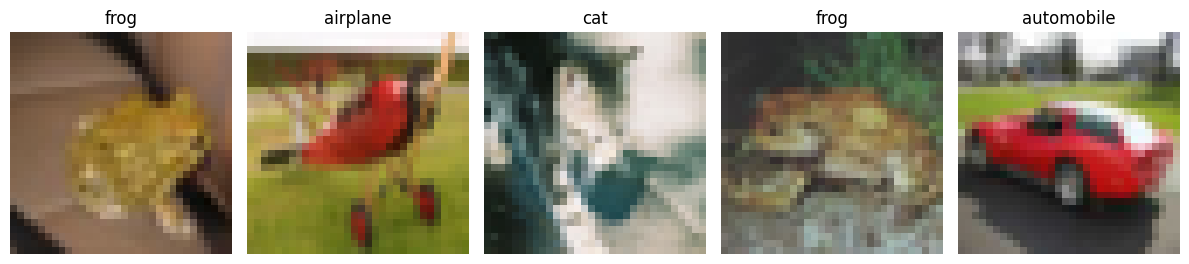

In [ ]:
show_random_images(x_train_small, y_train_small, num_images=5)

In [ ]:
# better visualization

def show_random_images2(images, labels, num_images=5):
    indices = random.sample(range(len(images)), num_images)

    plt.figure(figsize=(10,5))
    for i, index in enumerate(indices):
        plt.subplot(1, num_images, i + 1)
        plt.imshow(images[index])

        label = labels[index][0]
        plt.title(class_names[label])
        plt.axis('off')

    plt.show()

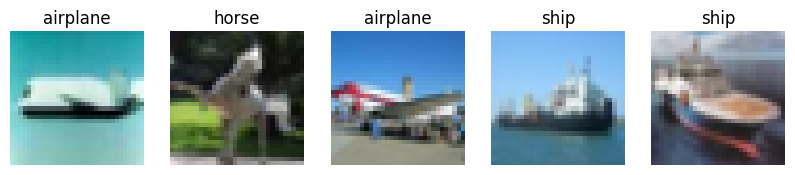

In [ ]:
show_random_images2(x_train_small, y_train_small, num_images=5)

## base line cnn model

In [ ]:
model_0 = Sequential([
    Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    MaxPool2D(2),
    Conv2D(32, 3, activation='relu'),
    Conv2D(32, 3, activation='relu'),
    MaxPool2D(2),
    Flatten(),
    Dense(10, activation='softmax')
])

model_0.compile(
    loss=CategoricalCrossentropy(),
    optimizer=SGD(learning_rate=0.01),
    metrics=['accuracy']
)

model_0.fit(
    x_train_small,
    y_train_small,
    epochs=5,
    validation_data=(x_test_small, y_test_small)
)

In [ ]:
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')  # CIFAR-10 has 10 classes
])